In [2]:
#Imported the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Step: Load the Dataset

The Titanic dataset is loaded into a Pandas DataFrame using the `read_csv()` function. This allows the dataset to be processed and analyzed using Python.

In [3]:
# Load the dataset

df = pd.read_csv("../data/Titanic-Dataset.csv")

## Step: Inspect the Dataset

Before cleaning the data, it is important to understand its structure. The following commands display the first few rows, dataset dimensions, column names, and general information about the dataset.

In [14]:
df.head()  #For the first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
df.tail() #For the last 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [16]:
df.info() #To get info on the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Step: Identify Missing Values

Missing values can negatively affect data analysis and machine learning models. The following code checks the number of missing values present in each column of the dataset.


In [17]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

### Observation

The dataset contains missing values in the **Age**, **Cabin**, and **Embarked** columns. Each column will be handled using an appropriate strategy based on the type of data and the proportion of missing values.

## Step 5: Handle Missing Values

Different techniques are used to handle missing values depending on the nature of each column.
The reasons for each change was explained.

In [50]:
df["Age"] = df["Age"].fillna(df["Age"].median()) # Filling missing values in the Age column using the median

The median is used because it is less affected by outliers than the mean.</br>
Replacing missing values with the median preserves the overall distribution of the data.</br>
This approach minimizes bias and ensures the dataset remains suitable for further analysis and machine learning.

In [51]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0]) # Filling missing values in the Embarked column using the mode

It is the standard technique for imputing missing values in categorical variables.</br>
Only two records contain missing values, so replacing them with the most common category has a negligible effect on the overall distribution.</br>
This approach preserves data consistency without removing any records from the dataset.

In [52]:
df.drop(columns=["Cabin"], inplace=True) # Removed Cabin column because it contains too many missing values

The Cabin column is removed because more than 75% of its values are missing.</br>
Filling such a large number of missing values would be unreliable.

In [54]:
df.info() #Verifying the cnahges

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


## Step: Check for Duplicate Records

Duplicate records can introduce bias into the analysis. The following code checks whether duplicate rows exist and removes them if necessary.

In [55]:
df.drop_duplicates(inplace=True)

In [56]:
df.info() #Verified the changes after removing the duplicates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


### Observation

The dataset was checked for duplicate records. Any duplicates found were removed to ensure that each passenger record is unique.

## Step: Verify Data Types

Each column's data type is examined to ensure it is appropriate for analysis. Incorrect data types can lead to inaccurate calculations and visualizations.

In [24]:
df.dtypes #Checking the data types in the sataset

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

### Observation
After reviewing the dataset, all columns were found to have appropriate data types.

- Numerical columns are stored as `int64` or `float64`.
- Text-based columns are stored as `object`.
- No date columns are present in the dataset.
Therefore, no data type conversion was necessary.

## Step: Generating Summary Statistics

Summary statistics provide an overview of the numerical and categorical features in the dataset. Numerical statistics are generated using `describe()`, while category frequencies are obtained using `value_counts()`.

In [25]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [57]:
df["Sex"].value_counts() # Display the frequency/occurrences of each gender

Sex
male      577
female    314
Name: count, dtype: int64

In [58]:
df["Embarked"].value_counts() # Display the frequency/occurrences of each embark port

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [59]:
df["Pclass"].value_counts() # Display the frequency/occurrences of passengers in each class

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

### Observation

The summary statistics reveal the distribution of numerical variables such as age and fare, while the frequency counts show the distribution of categorical variables including passenger class, gender, embarkation port, and survival status.

## Step: Visualize Age Distribution

A histogram is used to visualize the distribution of passenger ages. This helps identify the most common age groups and observe the overall spread of the data.

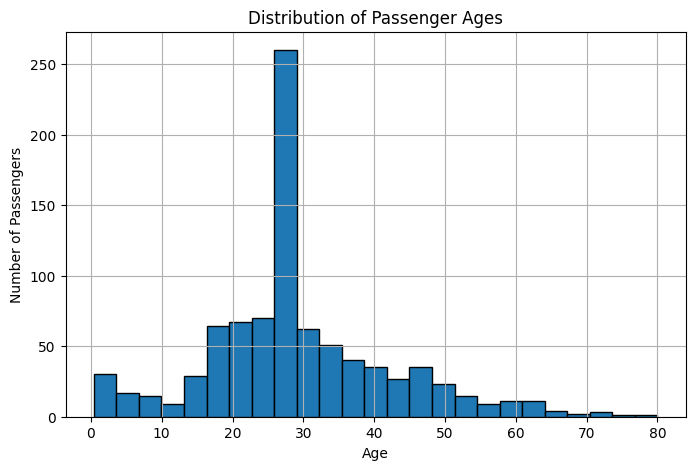

In [64]:
plt.figure(figsize=(8,5))

df["Age"].hist(bins=25, edgecolor="black")

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The histogram shows that most passengers were between **20 and 40 years** of age. There were relatively fewer children and elderly passengers on board.

## Step: Visualize Survival Distribution

A bar chart is used to compare the number of passengers who survived with those who did not survive the disaster.

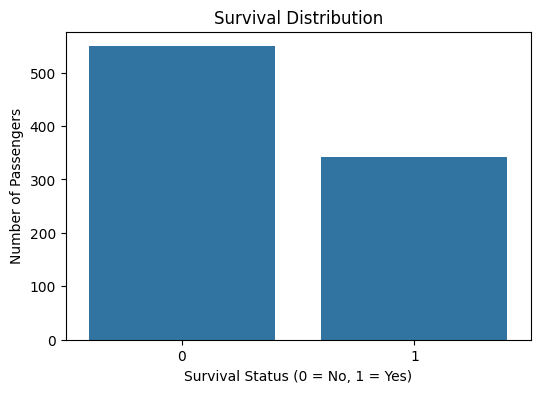

In [65]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=df)

plt.title("Survival Distribution")
plt.xlabel("Survival Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.savefig("../images/survival_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The chart indicates that the number of passengers who did not survive was greater than the number who survived.

## Step: Visualize Gender Distribution

This bar chart displays the number of male and female passengers in the dataset.

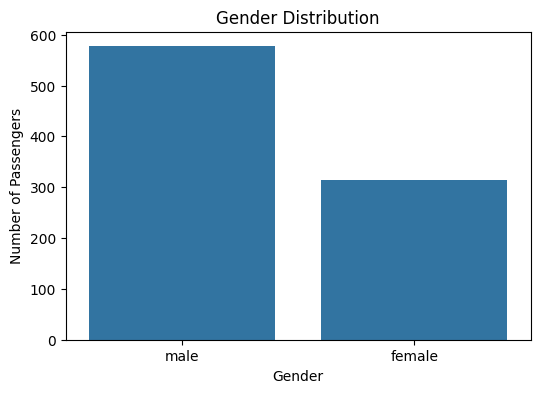

In [66]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.savefig("../images/sex_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The dataset contains a larger number of male passengers compared to female passengers.

## Step: Fare Distribution by Passenger Class

A box plot is used to compare ticket fares across the three passenger classes and identify differences in fare distribution.

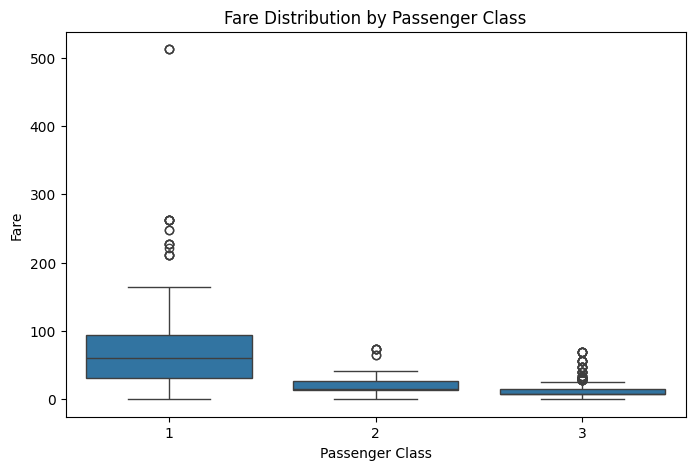

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Pclass", y="Fare", data=df)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.savefig("../images/fare_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

First-class passengers generally paid significantly higher fares than passengers in second and third class, indicating a clear relationship between passenger class and ticket price.

# Conclusion

The Titanic dataset was successfully cleaned and explored using Python. Missing values were handled appropriately, duplicate records were removed, and data types were verified. Summary statistics and visualizations provided valuable insights into passenger demographics, survival patterns, and fare distributions. This cleaned dataset is now ready for further machine learning analysis and model development.